# Pandas 실습 2

### 1. 데이터 준비
- 서울시 공공자전거(따릉이) 대여 데이터

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform
import pandas as pd

In [2]:
# 데이터 로드
df1 = pd.read_csv('data/서울특별시 공공자전거 일별 대여건수_25.7-12.csv', encoding='cp949')
df1.head()

,대여일자,대여건수
0,2025-07-01,132914
1,2025-07-02,151653
2,2025-07-03,151092
3,2025-07-04,151367
4,2025-07-05,118354


In [3]:
# 데이터 로드
df2 = pd.read_csv('data/서울특별시 공공자전거 대여소별 이용정보(월별)_25.7-12.csv')
df2.head()

,자치구,대여소명,기준년월,대여건수,반납건수
0,마포구,108. 서교동 사거리,202507,1277,1314
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218
3,양천구,733. 신정이펜하우스314동,202507,876,375
4,양천구,734. 신트리공원 입구,202507,2987,2958


In [9]:
# df1의 일자별 대여건수 top10
df1.shape
df1['대여일자'].value_counts()
df1['대여일자'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [10]:
# '대여일자' 데이터 타입 변환, to_datetime()
df1['대여일자'] = pd.to_datetime(df1['대여일자'])
df1.dtypes
df1['Year'] = df1['대여일자'].dt.year
df1['Month'] = df1['대여일자'].dt.month
df1['Day'] = df1['대여일자'].dt.day
df1['Month'].value_counts()

Month
7     31
8     31
10    31
12    31
9     30
11    30
Name: count, dtype: int64

In [11]:
# df1의 2025년도 월별 대여건수 
df1_rentals = df1.groupby('Month')['Month'].sum()
df1_rentals
df1_rentals.index
#df1_rentals.values

Index([7, 8, 9, 10, 11, 12], dtype='int32', name='Month')

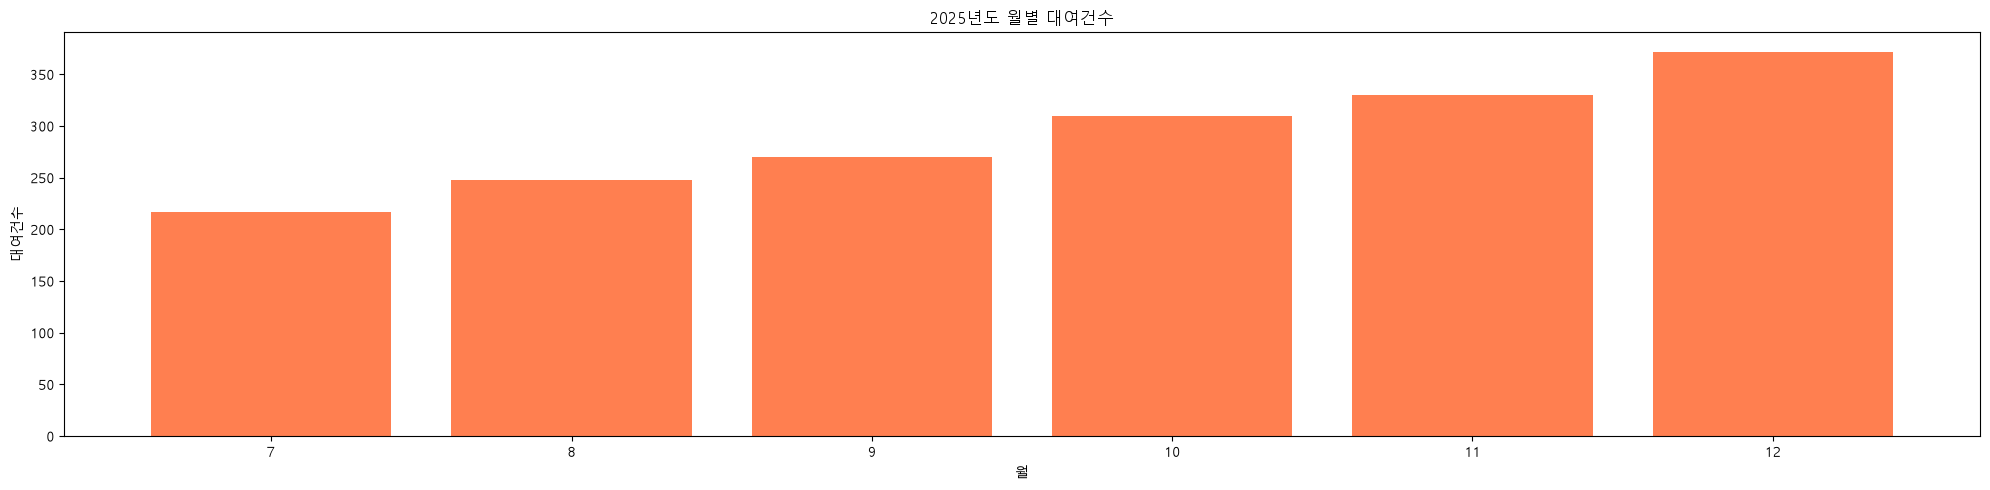

In [12]:
# 막대 그래프
plt.figure(figsize=(20, 5))
plt.bar(df1_rentals.index, df1_rentals.values, color='coral')
plt.title('2025년도 월별 대여건수')
plt.xlabel('월')
plt.ylabel('대여건수')
# plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# df2의 대여소별 대여건수 top5
df2.head()
#df2['대여소 명'].value_counts()

In [14]:
df1

,대여일자,대여건수,Year,Month,Day
0,2025-07-01,132914,2025,7,1
1,2025-07-02,151653,2025,7,2
2,2025-07-03,151092,2025,7,3
3,2025-07-04,151367,2025,7,4
4,2025-07-05,118354,2025,7,5
...,...,...,...,...,...
179,2025-12-27,42381,2025,12,27
180,2025-12-28,40774,2025,12,28
181,2025-12-29,66652,2025,12,29
182,2025-12-30,71026,2025,12,30


In [15]:
df1['대여일자'].dt.weekday

0      1
1      2
2      3
3      4
4      5
      ..
179    5
180    6
181    0
182    1
183    2
Name: 대여일자, Length: 184, dtype: int32

In [17]:
# 0:월요일, 1:화요일...
# 'weekday' 컬럼을 생성하고 요일 정보를 저장
df1['weekday'] = df1['대여일자'].dt.weekday
df1

,대여일자,대여건수,Year,Month,Day,weekday
0,2025-07-01,132914,2025,7,1,1
1,2025-07-02,151653,2025,7,2,2
2,2025-07-03,151092,2025,7,3,3
3,2025-07-04,151367,2025,7,4,4
4,2025-07-05,118354,2025,7,5,5
...,...,...,...,...,...,...
179,2025-12-27,42381,2025,12,27,5
180,2025-12-28,40774,2025,12,28,6
181,2025-12-29,66652,2025,12,29,0
182,2025-12-30,71026,2025,12,30,1


In [27]:
# 요일을 매핑하는 딕셔너리 객체 생성
week_dict = {
    0 : '월',
    1 : '화',
    2 : '수',
    3 : '목',
    4 : '금',
    5 : '토',
    6 : '일'
}
df1['weekday'] = df1['대여일자'].dt.weekday.map(week_dict)

In [26]:
df1.head()

,대여일자,대여건수,Year,Month,Day,weekday
0,2025-07-01,132914,2025,7,1,화
1,2025-07-02,151653,2025,7,2,수
2,2025-07-03,151092,2025,7,3,목
3,2025-07-04,151367,2025,7,4,금
4,2025-07-05,118354,2025,7,5,토


In [38]:
df1['weekday'].value_counts()
result = df1.groupby('weekday')['대여건수'].sum().sort_values(ascending=False)

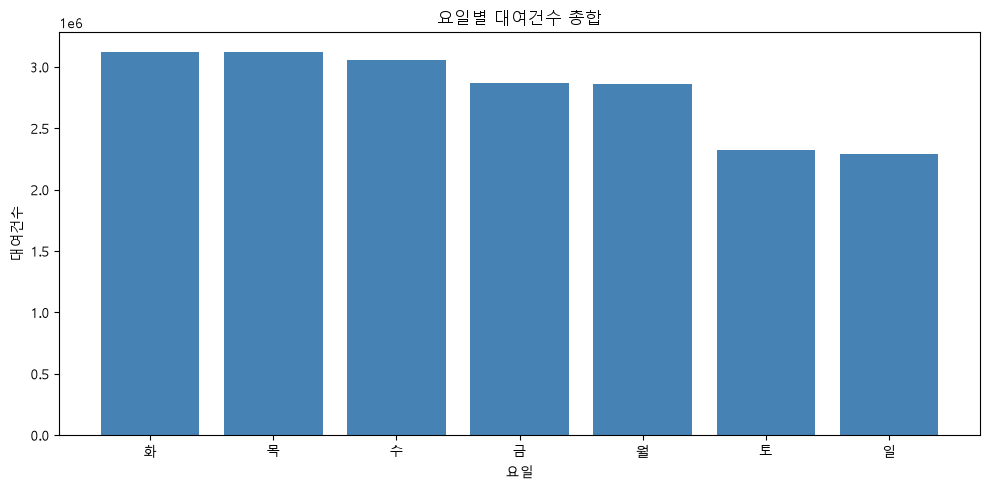

In [42]:
# 요일별 대여건수 그래프 작성
plt.figure(figsize=(10, 5))
plt.bar(result.index, result.values, color='steelblue')
plt.title('요일별 대여건수 총합')
plt.xlabel('요일')
plt.ylabel('대여건수')
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

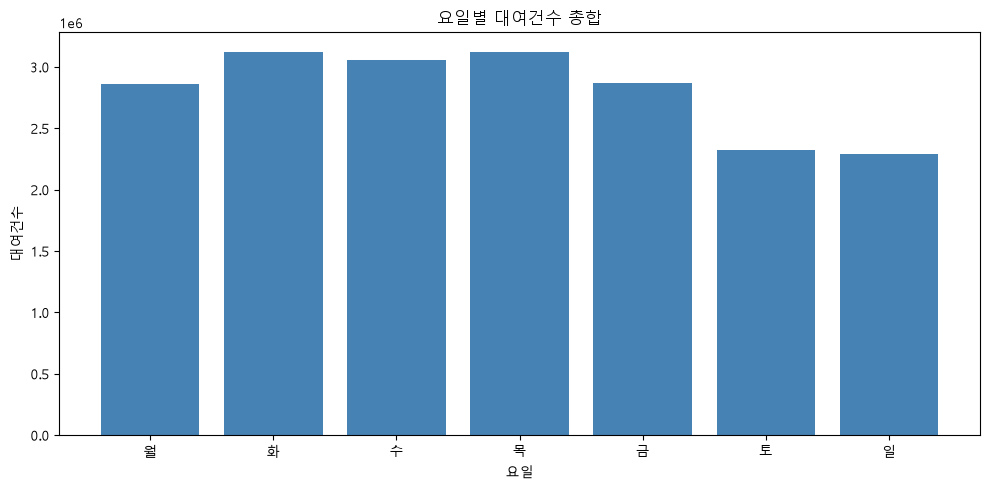

In [44]:
# 요일별 대여건수 그래프 작성
order = ['월', '화', '수', '목', '금', '토', '일']
result = df1.groupby('weekday')['대여건수'].sum().reindex(order)

plt.figure(figsize=(10, 5))
plt.bar(result.index, result.values, color='steelblue')
plt.title('요일별 대여건수 총합')
plt.xlabel('요일')
plt.ylabel('대여건수')
plt.tight_layout()
plt.show()

In [80]:
df2.head()

,자치구,대여소명,기준년월,대여건수,반납건수
0,마포구,108. 서교동 사거리,202507,1277,1314
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218
3,양천구,733. 신정이펜하우스314동,202507,876,375
4,양천구,734. 신트리공원 입구,202507,2987,2958


In [4]:
df2.rename(columns={'대여소 그룹':'그룹'})
df2.columns = ['그룹', '대여소', '일자', '건수', '반납건수']
df2

,그룹,대여소,일자,건수,반납건수
0,마포구,108. 서교동 사거리,202507,1277,1314
1,양천구,729. 서부식자재마트 건너편,202507,1658,1808
2,양천구,731. 서울시 도로환경관리센터,202507,3135,3218
3,양천구,733. 신정이펜하우스314동,202507,876,375
4,양천구,734. 신트리공원 입구,202507,2987,2958
...,...,...,...,...,...
16563,중랑구,4842. 면목라온프라이빗 아파트,202512,336,340
16564,중랑구,4843. 봉화산역 4번 출구,202512,436,516
16565,중랑구,4845. 신내역금강펜테리움센트럴파크,202512,163,106
16566,중랑구,4846. 상봉동양엔파트 앞,202512,482,489


In [55]:
# 대여소별 대여건수 Top5
df2['대여소'].value_counts()
station_top5 = df2.groupby('대여소')['건수'].sum().sort_values(ascending=False).head(5)
station_top5

대여소
2715.마곡나루역 2번 출구           86780
2728.마곡나루역 3번 출구           59620
1210. 롯데월드타워(잠실역2번출구 쪽)    58147
2701. 마곡나루역 5번출구 뒤편        55683
230. 영등포구청역 7번출구           47229
Name: 건수, dtype: int64

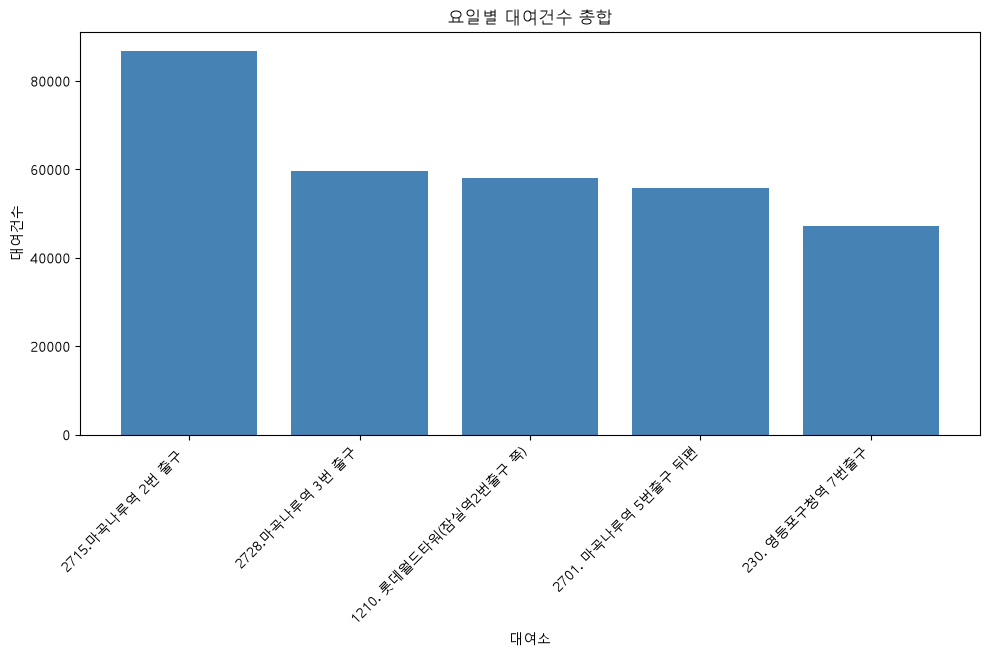

In [59]:
# 대여소별 대여건수 그래프
plt.figure(figsize=(10, 5))
plt.bar(station_top5.index, station_top5.values, color='steelblue')
plt.title('요일별 대여건수 총합')
plt.xlabel('대여소')
plt.ylabel('대여건수')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

### 그룹별 총 대여건수 Top 10

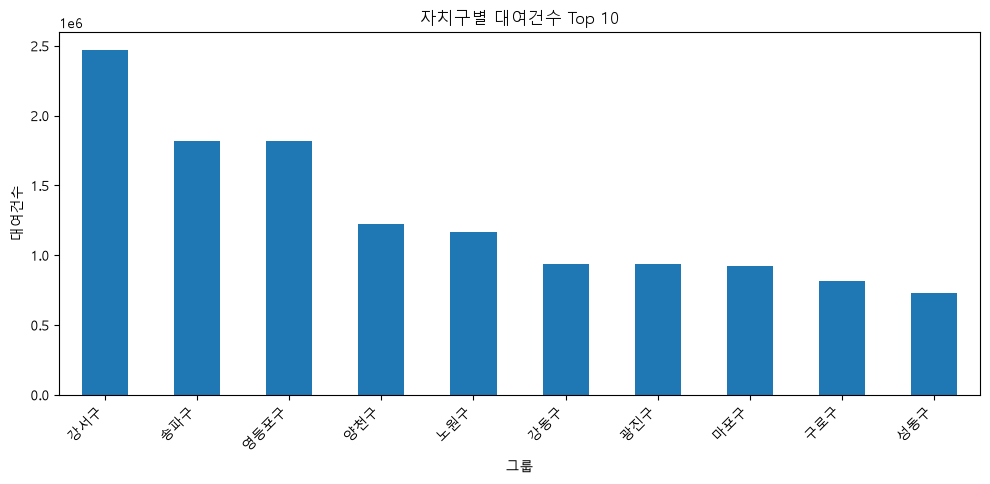

In [63]:
df2.head()
gu_top10 = df2.groupby('그룹')['건수'].sum().sort_values(ascending=False).head(10)
gu_top10.plot(
    kind = 'bar',
    figsize = (10,5),
)
plt.title('자치구별 대여건수 Top 10')
plt.ylabel('대여건수')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

### 월별 전체 대여건수 Top 10

In [6]:
df2['일자'] = pd.to_datetime(df2['일자'], format='%Y%m')
df2['월'] = df2['일자'].dt.month
month_rent = df2.groupby('월')['건수'].sum()
month_rent

월
7     3536203
8     3559263
9     3992326
10    3407811
11    3186985
12    1965174
Name: 건수, dtype: int64

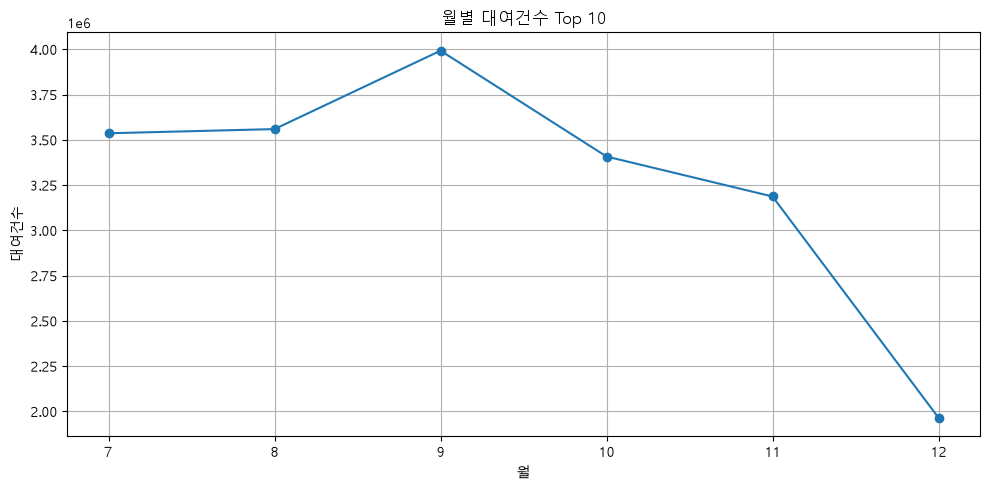

In [20]:
month_rent.plot(
    kind = 'line',
    marker='o',
    figsize = (10,5),
)
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False
plt.title('월별 대여건수 Top 10')
plt.ylabel('대여건수')
plt.grid()
plt.tight_layout()

### 대여소별 평균 대여건수 Top 15

In [12]:
df2.head(5)
group_mean = df2.groupby('대여소')['건수'].mean().sort_values(ascending=False).head(15)
group_mean

대여소
2715.마곡나루역 2번 출구           14463.333333
2728.마곡나루역 3번 출구            9936.666667
1210. 롯데월드타워(잠실역2번출구 쪽)     9691.166667
2701. 마곡나루역 5번출구 뒤편         9280.500000
230. 영등포구청역 7번출구            7871.500000
1153. 발산역 1번, 9번 인근 대여소     7612.166667
5515.한강버스 망원 선착장            7212.400000
502. 자양(뚝섬한강공원)역 1번출구 앞     6898.666667
2608. 송파구청                  6188.500000
1124. 발산역 6번 출구 뒤           6035.166667
2622. 올림픽공원역 3번출구           5834.166667
5052. 마곡역 7번출구              5651.000000
1911. 구로디지털단지역 앞            5582.000000
769.CBS방송국 앞                5524.666667
1160. 양천향교역 7번출구앞           5497.666667
Name: 건수, dtype: float64

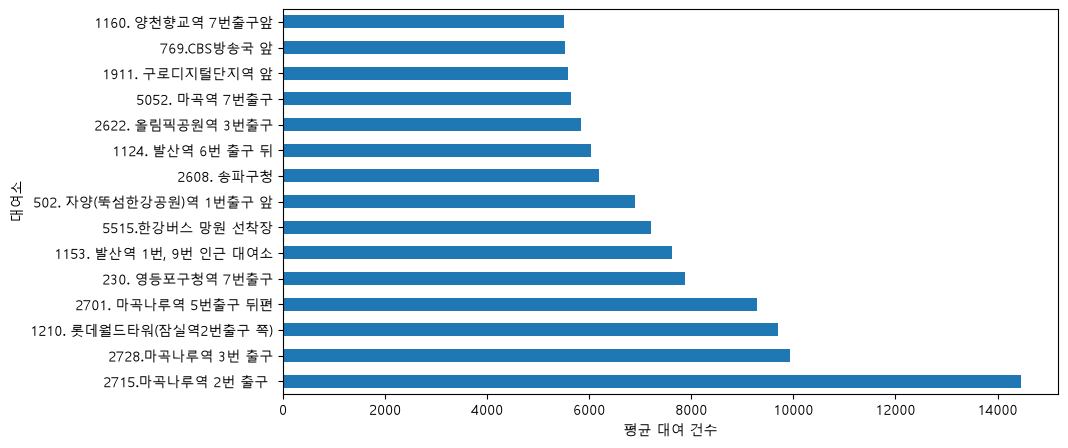

In [19]:
#그래프 시각화
group_mean.plot(
    kind='barh',
    figsize=(10,5)
)
plt.xlabel('평균 대여 건수')
plt.show()